In [ ]:
!pip install -q MDAnalysis MDTraj torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 9.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 93.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 106.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 120.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 4.8 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
output_dir = '/content/drive/MyDrive/ABE_RF_Diffusion/GNN_AC/HIVPR/METHODS/MethodC/WT/'
os.makedirs(output_dir, exist_ok=True)

print(f"Working directory created at: {output_dir}")

Working directory created at: /content/drive/MyDrive/ABE_RF_Diffusion/GNN_AC/HIVPR/MethodC/WT/


In [ ]:
import os
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from MDAnalysis import Universe
from tqdm import tqdm

In [ ]:
import torch

data_file = os.path.join(output_dir, 'trajectory_graphs_phi_psi_rmsf_WT_rep1.pt')
data = torch.load(data_file, weights_only=False)

print(f"Loaded {len(data)} graph frames.")
print("Node feature shape:", data[0].x.shape)
print("Edge feature shape:", data[0].edge_attr.shape)


Loaded 4000 graph frames.
Node feature shape: torch.Size([198, 6])
Edge feature shape: torch.Size([3348, 3])


In [ ]:
#Method C is GAT-EG
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax

class EdgeGATConv_MethodC(MessagePassing):
    def __init__(self, in_channels, out_channels, edge_dim=3, heads=1, concat=True, dropout=0.0, bias=True):
        super().__init__(aggr='add', node_dim=0)

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.heads = heads
        self.concat = concat
        self.dropout = dropout

        # Node projection
        self.lin = nn.Linear(in_channels, heads * out_channels, bias=False)

        # Edge projection for attention score
        self.edge_lin = nn.Linear(edge_dim, heads * out_channels, bias=False)

        # Separate edge projection for message gating
        self.edge_gate = nn.Linear(edge_dim, heads * out_channels, bias=True)

        # Attention parameters: [x_i || x_j || edge_attr]
        self.att = nn.Parameter(torch.empty(heads, 3 * out_channels))
        self.leaky_relu = nn.LeakyReLU(0.2)

        if bias:
            self.bias = nn.Parameter(torch.Tensor(heads * out_channels if concat else out_channels))
        else:
            self.register_parameter('bias', None)

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.lin.weight)
        nn.init.xavier_uniform_(self.edge_lin.weight)
        nn.init.xavier_uniform_(self.edge_gate.weight)
        nn.init.zeros_(self.edge_gate.bias)
        nn.init.xavier_uniform_(self.att)

        if self.bias is not None:
            nn.init.zeros_(self.bias)

    def forward(self, x, edge_index, edge_attr):
        # x: [N, in_channels]
        # edge_attr: [E, edge_dim]

        x = self.lin(x)                              # [N, H*C]
        edge_att = self.edge_lin(edge_attr)          # [E, H*C]
        edge_gate = self.edge_gate(edge_attr)        # [E, H*C]

        return self.propagate(
            edge_index=edge_index,
            x=x,
            edge_att=edge_att,
            edge_gate=edge_gate
        )

    def message(self, x_i, x_j, edge_att, edge_gate, index):
        x_i = x_i.view(-1, self.heads, self.out_channels)
        x_j = x_j.view(-1, self.heads, self.out_channels)

        edge_att = edge_att.view(-1, self.heads, self.out_channels)
        edge_gate = edge_gate.view(-1, self.heads, self.out_channels)

        # Attention score remains edge-aware
        cat = torch.cat([x_i, x_j, edge_att], dim=-1)
        alpha = torch.einsum("ehc,hc->eh", cat, self.att)
        alpha = self.leaky_relu(alpha)
        alpha = softmax(alpha, index)
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)

        # Method C: edge-gated message
        gate = torch.sigmoid(edge_gate)
        msg = x_j * gate

        return msg * alpha.unsqueeze(-1)

    def update(self, aggr_out):
        if self.concat:
            aggr_out = aggr_out.view(-1, self.heads * self.out_channels)
        else:
            aggr_out = aggr_out.mean(dim=1)

        if self.bias is not None:
            aggr_out += self.bias

        return aggr_out

In [ ]:
class EdgeGATDynamics(nn.Module):
    def __init__(self, in_features=6, hidden_dim=128, out_features=3, heads=4):
        super().__init__()
        self.gat1 = EdgeGATConv_MethodC(in_features, hidden_dim, edge_dim=3, heads=heads, concat=True)
        self.gat2 = EdgeGATConv_MethodC(hidden_dim * heads, hidden_dim, edge_dim=3, heads=heads, concat=True)
        self.gat3 = EdgeGATConv_MethodC(hidden_dim * heads, hidden_dim, edge_dim=3, heads=heads, concat=True)
        self.gat4 = EdgeGATConv_MethodC(hidden_dim * heads, hidden_dim, edge_dim=3, heads=1, concat=False)
        self.fc = nn.Linear(hidden_dim, out_features)
        self.bias = nn.Parameter(torch.ones(1))

    def forward(self, x, edge_index, edge_attr):
        x = self.gat1(x, edge_index, edge_attr)
        x = F.relu(x)
        x = self.gat2(x, edge_index, edge_attr)
        x = F.relu(x)
        x = self.gat3(x, edge_index, edge_attr)
        x = F.relu(x)
        x = self.gat4(x, edge_index, edge_attr)
        out = self.fc(x)
        return out * self.bias


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
from torch.optim import Adam

# ====== Load your data ======
data_file = os.path.join(output_dir, 'trajectory_graphs_phi_psi_rmsf_WT_rep1.pt')
data = torch.load(data_file, weights_only=False)

print(f"Loaded {len(data)} graph frames.")
print("Node feature shape:", data[0].x.shape)
print("Edge feature shape:", data[0].edge_attr.shape)

data_list = [d.to('cuda' if torch.cuda.is_available() else 'cpu') for d in data]

# ====== Model, optimizer, loss ======
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = EdgeGATDynamics(in_features=6, hidden_dim=128, out_features=3, heads=4).to(device)
optimizer = Adam(model.parameters(), lr=5e-4)  # 🔽 Lower LR for stability
loss_fn = nn.MSELoss()

# ====== Training settings ======
epochs = 100
patience = 20
best_loss = float('inf')
counter = 0

model_save_path = os.path.join(output_dir, "edgegat_dynamics_best_WT_rep1.pt")

# ====== Training loop ======
for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0.0

    for i in range(len(data_list) - 1):
        data_curr = data_list[i]
        data_next = data_list[i + 1]

        optimizer.zero_grad()
        pred = model(data_curr.x, data_curr.edge_index, data_curr.edge_attr)
        target = data_next.x[:, :3]  # ⬅️ Only coordinate portion
        loss = loss_fn(pred, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / (len(data_list) - 1)
    print(f"Epoch {epoch:3d} | Avg Loss: {avg_loss:.6f}")

    # Save best model
    if avg_loss < best_loss:
        best_loss = avg_loss
        counter = 0
        torch.save(model.state_dict(), model_save_path)
        print(f"✅ Best model saved! Loss: {best_loss:.6f}")
    else:
        counter += 1
        if counter >= patience:
            print(f"⏹️ Early stopping at epoch {epoch} (no improvement for {patience} epochs)")
            break

Loaded 4000 graph frames.
Node feature shape: torch.Size([198, 6])
Edge feature shape: torch.Size([3348, 3])
Epoch   1 | Avg Loss: 8.427202
✅ Best model saved! Loss: 8.427202
Epoch   2 | Avg Loss: 0.785490
✅ Best model saved! Loss: 0.785490
Epoch   3 | Avg Loss: 0.607456
✅ Best model saved! Loss: 0.607456
Epoch   4 | Avg Loss: 0.473065
✅ Best model saved! Loss: 0.473065
Epoch   5 | Avg Loss: 0.392816
✅ Best model saved! Loss: 0.392816
Epoch   6 | Avg Loss: 0.340855
✅ Best model saved! Loss: 0.340855
Epoch   7 | Avg Loss: 0.308453
✅ Best model saved! Loss: 0.308453
Epoch   8 | Avg Loss: 0.285598
✅ Best model saved! Loss: 0.285598
Epoch   9 | Avg Loss: 0.268210
✅ Best model saved! Loss: 0.268210
Epoch  10 | Avg Loss: 0.255733
✅ Best model saved! Loss: 0.255733
Epoch  11 | Avg Loss: 0.245132
✅ Best model saved! Loss: 0.245132
Epoch  12 | Avg Loss: 0.236989
✅ Best model saved! Loss: 0.236989
Epoch  13 | Avg Loss: 0.229399
✅ Best model saved! Loss: 0.229399
Epoch  14 | Avg Loss: 0.223240
✅ 

In [ ]:
model_path = os.path.join(output_dir, "edgegat_dynamics_best_WT_rep1.pt")
data_file = os.path.join(output_dir, 'trajectory_graphs_phi_psi_rmsf_WT_rep1.pt')

In [ ]:
import os
import torch

# Set the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = EdgeGATDynamics(in_features=6, hidden_dim=128, out_features=3, heads=4).to(device)

# Load the data
data_list_cpu = torch.load(data_file, weights_only=False)
data_list = [d.to(device) for d in data_list_cpu] # Move data to the correct device

model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

print("✅ Model loaded successfully on device:", device)

✅ Model loaded successfully on device: cuda


In [ ]:
def kabsch_align(P, Q):
    """
    Aligns P (pred) to Q (true) using Kabsch algorithm.
    Returns: P_aligned [N, 3]
    """
    # Subtract centroids
    P_mean = P.mean(dim=0, keepdim=True)
    Q_mean = Q.mean(dim=0, keepdim=True)

    P_centered = P - P_mean
    Q_centered = Q - Q_mean

    # Compute covariance matrix
    C = torch.matmul(P_centered.T, Q_centered)

    # SVD
    V, S, Wt = torch.linalg.svd(C)
    d = torch.det(torch.matmul(V, Wt))
    D = torch.diag(torch.tensor([1., 1., d], device=P.device))

    # Rotation
    U = torch.matmul(torch.matmul(V, D), Wt)

    # Rotate and re-center
    P_rot = torch.matmul(P_centered, U)

    return P_rot + Q_mean

In [ ]:
def compute_kabsch_rmsd(P, Q):
    P_aligned = kabsch_align(P, Q)
    return torch.sqrt(((P_aligned - Q) ** 2).sum(dim=1).mean()).item()

In [ ]:
model.eval()
kabsch_rmsds = []

with torch.no_grad():
    for i in range(len(data_list) - 1):
        d0 = data_list[i]
        d1 = data_list[i + 1]

        pred = model(d0.x, d0.edge_index, d0.edge_attr)
        true = d1.x[:, :3]

        rmsd_kabsch = compute_kabsch_rmsd(pred, true)
        kabsch_rmsds.append(rmsd_kabsch)

print(f"\n✅ Kabsch-aligned RMSD: {np.mean(kabsch_rmsds):.3f} Å")



✅ Kabsch-aligned RMSD: 0.833 Å


100%|██████████| 3999/3999 [00:20<00:00, 193.65it/s]


📁 Saved RMSD plot to: /content/drive/MyDrive/ABE_RF_Diffusion/GNN_AC/HIVPR/MethodB/NAM/kabsch_rmsd_true_pred_rep3.png
Mean RMSD = 0.833 Å


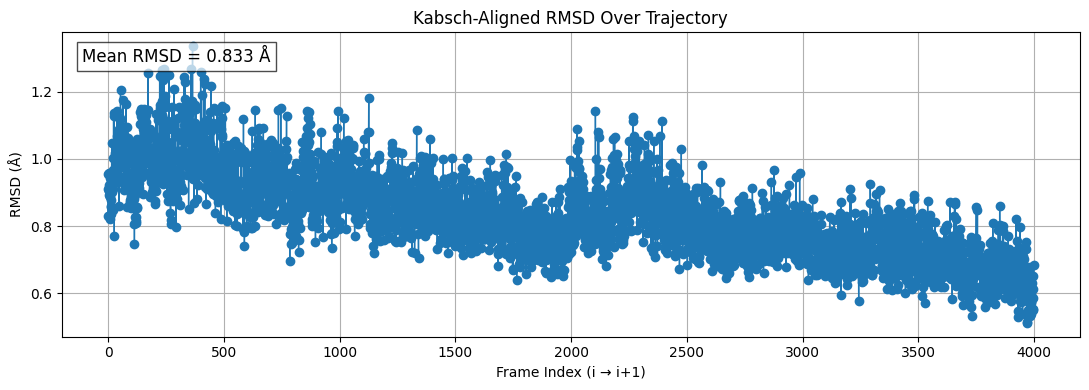

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

kabsch_rmsds = []

model.eval()
with torch.no_grad():
    for i in tqdm(range(len(data_list) - 1)):
        d0 = data_list[i]
        d1 = data_list[i + 1]

        pred = model(d0.x, d0.edge_index, d0.edge_attr)
        true = d1.x[:, :3]

        rmsd_kabsch = compute_kabsch_rmsd(pred, true)
        kabsch_rmsds.append(rmsd_kabsch)

# Convert to numpy
kabsch_rmsds = np.array(kabsch_rmsds)
frame_indices = np.arange(len(kabsch_rmsds))

# === FIGURE CREATION ===
fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(frame_indices, kabsch_rmsds, marker='o', linewidth=1)
ax.set_title("Kabsch-Aligned RMSD Over Trajectory")
ax.set_xlabel("Frame Index (i → i+1)")
ax.set_ylabel("RMSD (Å)")
ax.grid(True)

mean_val = kabsch_rmsds.mean()

# === ADD MEAN RMSD TEXT ON PLOT ===
ax.text(
    0.02, 0.95,
    f"Mean RMSD = {mean_val:.3f} Å",
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="black")
)

fig.tight_layout()

# === SAVE PNG ===
out_file = "/content/drive/MyDrive/ABE_RF_Diffusion/GNN_AC/HIVPR/METHODS/MethodC/WT/kabsch_rmsd_true_pred_rep1.png"
fig.savefig(out_file, dpi=300, transparent=False)

print(f"📁 Saved RMSD plot to: {out_file}")
print(f"Mean RMSD = {mean_val:.3f} Å")

plt.show()
plt.close(fig)

100%|██████████| 3999/3999 [00:23<00:00, 166.73it/s]


📁 Saved RMSD plot to: /content/drive/MyDrive/ABE_RF_Diffusion/GNN_AC/HIVPR/MethodB/NAM/rmsd_firstframe_true_pred_rep3.png


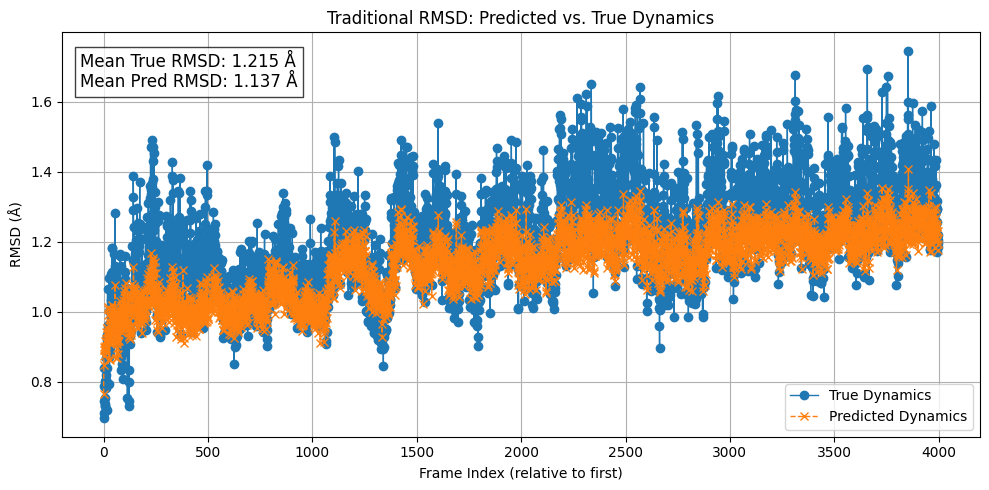

✅ Mean True Dynamics RMSD: 1.215 Å
Min: 0.696 Å | Max: 1.746 Å
✅ Mean Predicted Dynamics RMSD: 1.137 Å
Min: 0.767 Å | Max: 1.409 Å


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# Store traditional RMSD for both predicted and true trajectories
pred_rmsds = []
true_rmsds = []

model.eval()
with torch.no_grad():
    # First frame as reference
    ref_frame = data_list[0].x[:, :3]

    for i in tqdm(range(len(data_list) - 1)):
        d0 = data_list[i]
        d1 = data_list[i + 1]

        pred = model(d0.x, d0.edge_index, d0.edge_attr)
        true = d1.x[:, :3]

        pred_rmsds.append(compute_kabsch_rmsd(pred, ref_frame))
        true_rmsds.append(compute_kabsch_rmsd(true, ref_frame))

# Convert to numpy
pred_rmsds = np.array(pred_rmsds)
true_rmsds = np.array(true_rmsds)
frame_indices = np.arange(len(pred_rmsds))

mean_true = true_rmsds.mean()
mean_pred = pred_rmsds.mean()

# === FIGURE CREATION (SAFE) ===
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(frame_indices, true_rmsds, label="True Dynamics", marker='o', linewidth=1)
ax.plot(frame_indices, pred_rmsds, label="Predicted Dynamics", marker='x', linewidth=1, linestyle='dashed')

ax.set_title("Traditional RMSD: Predicted vs. True Dynamics")
ax.set_xlabel("Frame Index (relative to first)")
ax.set_ylabel("RMSD (Å)")
ax.grid(True)
ax.legend()

# === ADD MEAN VALUES TEXT TO PLOT ===
text_str = (
    f"Mean True RMSD: {mean_true:.3f} Å\n"
    f"Mean Pred RMSD: {mean_pred:.3f} Å"
)

ax.text(
    0.02, 0.95, text_str,
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(facecolor="white", alpha=0.75, edgecolor="black")
)

fig.tight_layout()

# === SAVE BEFORE SHOW ===
out_file = "/content/drive/MyDrive/ABE_RF_Diffusion/GNN_AC/HIVPR/METHODS/MethodC/WT/rmsd_firstframe_true_pred_rep1.png"
fig.savefig(out_file, dpi=300, transparent=False)

print(f"📁 Saved RMSD plot to: {out_file}")

# Show the figure (optional)
plt.show()
plt.close(fig)

# === PRINT STATS IN TERMINAL ===
print(f"✅ Mean True Dynamics RMSD: {mean_true:.3f} Å")
print(f"Min: {true_rmsds.min():.3f} Å | Max: {true_rmsds.max():.3f} Å")

print(f"✅ Mean Predicted Dynamics RMSD: {mean_pred:.3f} Å")
print(f"Min: {pred_rmsds.min():.3f} Å | Max: {pred_rmsds.max():.3f} Å")
